# MRI Data Exploration

Explore anatomical and diffusion MRI volumes, cortical parcellation labels, and the spatial effects of fractional anisotropy thresholding.

Run this notebook from the project root. See the [project overview](README.md) for the full analysis workflow.


## Introduction

The human connectome can be described at two complementary levels: structural connectivity, which describes the density of white-matter tracts between cortical regions; and functional connectivity, which measures the correlation of concurrent neural activity between regions. Understanding how structural connectivity contrains or enables functional connectivity is a fundamental question in neuroscience.

In our project, structural connectivity is measured using weighted fractional anisotropy (WFA) taken from diffusion tensor imaging tractography. WFA combines fibre count and diffusion anisotropy to give a continuous measure of connection strength between 0 and 1. Functional connectivity is calculated from resting-state fMRI (rsfMRI), where the Pearson correlation between the time series of each region pair acts as a measure of co-activation during rest. This report explores the relationship between the two using graph theory.

## Data

19 healthy adults (IDs 32-50) each provide a 68x68 structural matrix and a 68x68 functional matrix parcellated using FreeSurfer. For core task 1, a single subject’s rsfMRI time series, consisting of 110 regions and 15 volumes, and FA-thresholded structural graphs [0.1, 0.8] are analysed.

The tractor files contain 3 file types:

1. T1w_vol1.nii.gz: A high-resolution 3D T1-weighted anatomical MRI for detailed brain structure
2. parcellation.nii.gz and parcellation.lut: Assigns each voxel to one of the 110 brain regions
3. dti_FA.nii.gz: 3D fractional anisotropy map derived from diffusion-weighted imaging (DWI), where each voxel has a value representing the directionality of water diffusion.

Tractography gives us paths connecting each pair of parcellated regions, and the mean FA along connecting bundles gives the weighted structural edge (WFA).

In [1]:
# Dependencies are listed in requirements.txt.
import nibabel
import nilearn


**Verification note:** The 19-subject functional matrices are supplied normalised precision matrices, as described in the original project brief. Pearson correlation and shrinkage are used for the separate single-subject fMRI analysis. WFA is a streamline-visit-weighted mean of FA, rather than a fibre-count measurement.

In [2]:
from pathlib import Path
import os
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx
import pandas as pd
import nibabel as nib
from nilearn import plotting

In [3]:
def parse_lut(filepath):
    """
    Parses a FreeSurfer-style .lut file and returns a dictionary 
    mapping the region ID to its name.
    """
    lut_dict = {}
    with open(filepath, 'r') as f:
        for line in f:
            # Skip empty lines or comments
            if not line.strip() or line.strip().startswith('#'):
                continue
            
            # Format is typically: ID Label R G B A
            parts = line.split()
            if len(parts) >= 2:
                try:
                    region_id = int(parts[0])
                    region_name = parts[1]
                    lut_dict[region_id] = region_name
                except (ValueError, IndexError):
                    # Ignore lines that don't fit the expected format
                    continue
    return lut_dict

# Path to the LUT file
lut_file_path = "data/mri/tractor/structural/parcellation.lut"

# Parse the file and store the mapping
region_labels = parse_lut(lut_file_path)

# Print the resulting dictionary
print(region_labels)

{0: 'unknown', 2: 'cerebral_white_matter_left', 4: 'lateral_ventricle_left', 5: 'inferior_lateral_ventricle_left', 7: 'cerebellar_white_matter_left', 8: 'cerebellar_cortex_left', 10: 'thalamus_left', 11: 'caudate_left', 12: 'putamen_left', 13: 'pallidum_left', 14: '3rd_ventricle', 15: '4th_ventricle', 16: 'brainstem', 17: 'hippocampus_left', 18: 'amygdala_left', 24: 'cerebrospinal_fluid', 26: 'accumbens_left', 28: 'NA', 30: 'NA', 31: 'choroid_plexus_left', 41: 'cerebral_white_matter_right', 43: 'lateral_ventricle_right', 44: 'inferior_lateral_ventricle_right', 46: 'cerebellar_white_matter_right', 47: 'cerebellar_cortex_right', 49: 'thalamus_right', 50: 'caudate_right', 51: 'putamen_right', 52: 'pallidum_right', 53: 'hippocampus_right', 54: 'amygdala_right', 58: 'accumbens_right', 60: 'NA', 62: 'NA', 63: 'choroid_plexus_right', 77: 'NA', 80: 'NA', 85: 'optic_chiasm', 251: 'corpus_callosum_posterior', 252: 'corpus_callosum_mid-posterior', 253: 'corpus_callosum_central', 254: 'corpus_call

In [4]:
table1_paths = [
    "tractor/structural/T1w_vol1.nii.gz",
    "tractor/structural/parcellation.nii.gz",
    "tractor/diffusion/data.nii.gz",
    "tractor/diffusion/dti_FA.nii.gz",
    "tractor/diffusion/parcellation.nii.gz",
    "tractor/functional/data.nii.gz",
    "tractor/functional/parcellation.nii.gz"
]

In [5]:
target_file = f"data/mri/{table1_paths[3]}"  

In [6]:
img = nib.load(target_file)

# get voxel data
data = np.nan_to_num(img.get_fdata(), nan=0.0, posinf=0.0, neginf=0.0)
# The FA volume uses non-finite values outside the brain; display them as background.
img = nib.Nifti1Image(data, img.affine, img.header)

print(data.shape)

(96, 96, 60)


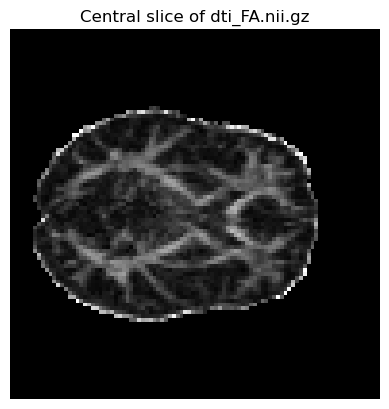

In [7]:
# Select a slice to display
slice_index = data.shape[2] // 2

# Prepare the data for plotting
plot_data = data

# If the data is 4D, we need to select a single 3D volume to display
if data.ndim == 4:
    print("Data is 4D, selecting the first volume for this 2D plot.")
    # Slicing to get a 2D image: [all_x, all_y, specific_z, first_volume]
    plot_data = data[:, :, slice_index, 0]
# If the data is 3D, just take the slice
elif data.ndim == 3:
    plot_data = data[:, :, slice_index]
else:
    # This will handle 2D data or raise an error for other shapes
    plot_data = data

plt.imshow(plot_data, cmap="gray")
plt.title(f"Central slice of {Path(target_file).name}")
plt.axis("off")
plt.show()

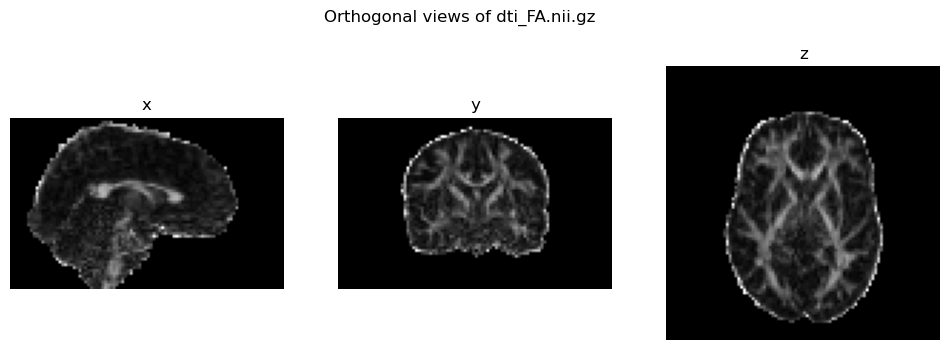

In [8]:
# Prepare the data for plotting
plot_data = data

# If the data is 4D, we need to select a single 3D volume to display
if data.ndim == 4:
    print("Data is 4D, selecting the first volume for these 2D plots.")
    plot_data = data[:, :, :, 0] # Select the first 3D volume
elif data.ndim != 3:
    print(f"Data has an unexpected shape of {data.shape}, skipping plotting.")
    plot_data = None

if plot_data is not None:
    x = plot_data.shape[0] // 2
    y = plot_data.shape[1] // 2
    z = plot_data.shape[2] // 2

    fig, ax = plt.subplots(1,3, figsize=(12,4))

    ax[0].imshow(plot_data[x,:,:].T, cmap="gray", origin="lower")
    ax[0].set_title("x")

    ax[1].imshow(plot_data[:,y,:].T, cmap="gray", origin="lower")
    ax[1].set_title("y")

    ax[2].imshow(plot_data[:,:,z].T, cmap="gray", origin="lower")
    ax[2].set_title("z")

    for a in ax:
        a.axis("off")
        
    fig.suptitle(f"Orthogonal views of {Path(target_file).name}")
    plt.show()

**Figure 1:** Orthogonal views (sagittal, coronal, axial) of the fractional anisotropy (FA) map for one subject. Bright voxels indicate high diffusion anisotropy characteristic of organised white-matter tracts; dark regions correspond to grey matter and CSF where diffusion is more isotropic.

Image is 3D, plotting directly.


C:\Users\james\anaconda3\Lib\site-packages\numpy\_core\fromnumeric.py:870: UserWarning: Warning: 'partition' will ignore the 'mask' of the MaskedArray.
  a.partition(kth, axis=axis, kind=kind, order=order)



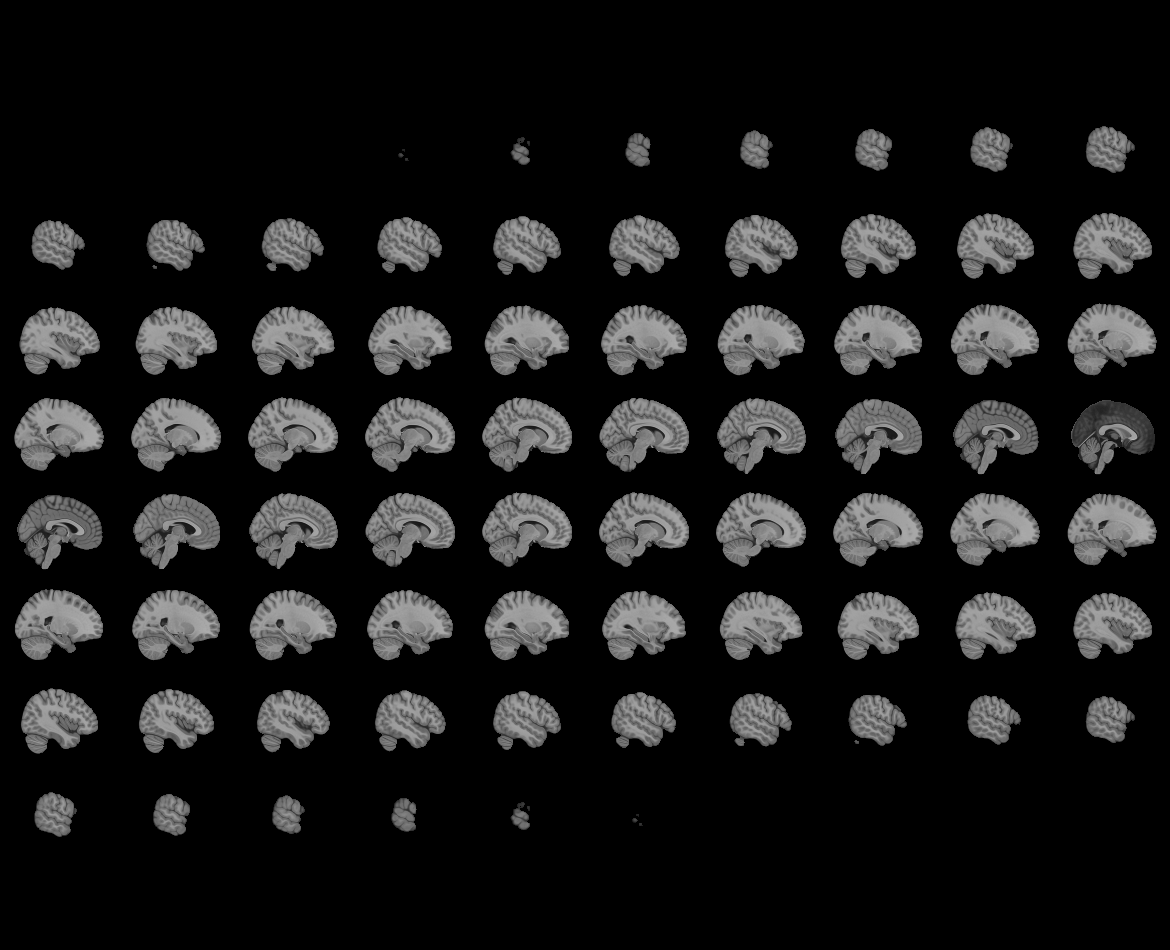
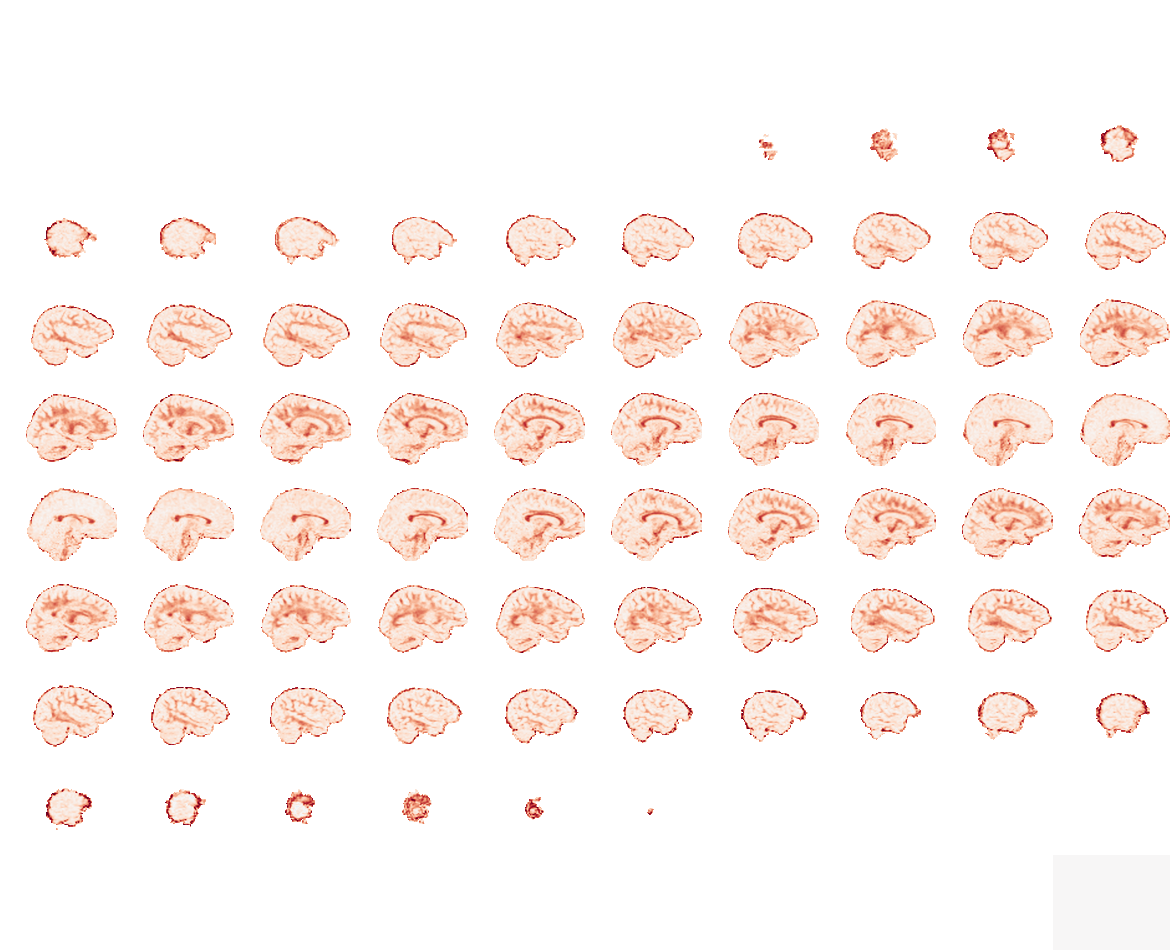

In [9]:
from nilearn import image

# Check the dimensionality of the loaded image
if img.ndim == 4:
    print("Image is 4D, selecting the first 3D volume for interactive plotting.")
    # Select the first 3D volume from the 4D image to display
    display_img = image.index_img(img, 0)
elif img.ndim == 3:
    print("Image is 3D, plotting directly.")
    display_img = img
else:
    print(f"Image has an unsupported dimension of {img.ndim}. Skipping interactive plot.")
    display_img = None

# if display_img:
plotting.view_img(display_img)

48


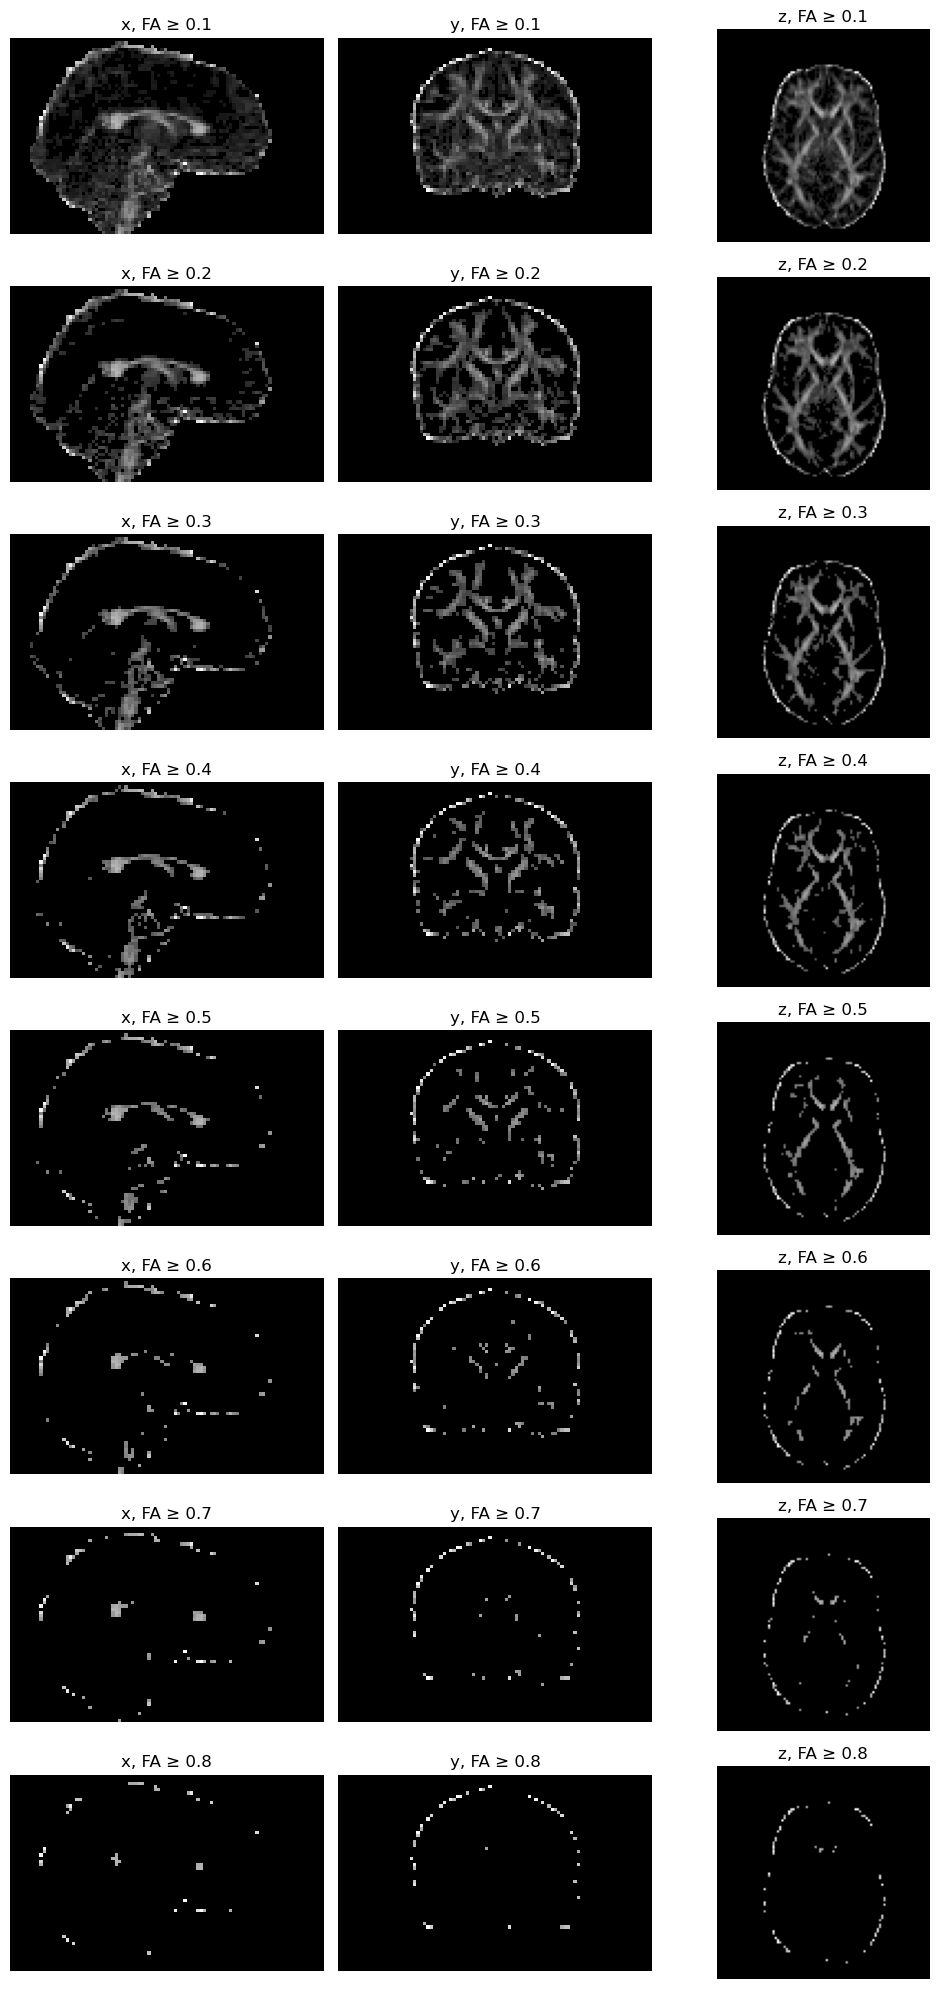

In [10]:
# FA MAP
fa = np.nan_to_num(nib.load(f"data/mri/{table1_paths[3]}").get_fdata(),
                   nan=0.0, posinf=0.0, neginf=0.0)


thresholds = np.arange(0.1, 0.9, 0.1)

x = fa.shape[0] // 2
print(x)
y = fa.shape[1] // 2
z = fa.shape[2] // 2

fig, axes = plt.subplots(len(thresholds), 3, figsize=(10, 2.5 * len(thresholds)))

for i, th in enumerate(thresholds):
    fa_thr = fa.copy()
    fa_thr[fa_thr < th] = 0

    axes[i, 0].imshow(fa_thr[x, :, :].T, cmap="gray", origin="lower")
    axes[i, 0].set_title(f"x, FA ≥ {th:.1f}")

    axes[i, 1].imshow(fa_thr[:, y, :].T, cmap="gray", origin="lower")
    axes[i, 1].set_title(f"y, FA ≥ {th:.1f}")

    axes[i, 2].imshow(fa_thr[:, :, z].T, cmap="gray", origin="lower")
    axes[i, 2].set_title(f"z, FA ≥ {th:.1f}")

    for j in range(3):
        axes[i, j].axis("off")

plt.tight_layout()
plt.show()

## Spatial Distribution of FA Thresholds

At the voxel level, increasing FA threshold acts as a filter of tissue type. At $FA \geq 0.1$ most of the brain volume is retained, including grey matter where water diffusion is relatively isotropic. As the threshold rises to $FA \geq 0.3-0.4$, isotropic grey matter is eliminated, leaving primarily the cores of major white matter tracts, where diffusion is strongly directional. At high thresholds ($FA \geq 0.6-0.8$) only sparse voxels remain in the densest fibre bundles, with most of the brain dark. This behaviour confirms that FA thresholding isolates the most structurally organised white matter.